In [6]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X,y= fetch_openml("adult",version=2,as_frame=True,return_X_y=True)

df=X.copy()
df['income']=y
df=df[["age","workclass","education","education-num","marital-status","occupation","race",'sex','capital-gain','capital-loss','hours-per-week','income']]
df=df.dropna()
df

,age,workclass,education,education-num,marital-status,occupation,race,sex,capital-gain,capital-loss,hours-per-week,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Black,Male,0,0,40,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,White,Male,0,0,50,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,White,Male,0,0,40,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Black,Male,7688,0,40,>50K
5,34,Private,10th,6,Never-married,Other-service,White,Male,0,0,30,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,White,Female,0,0,38,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,White,Male,0,0,40,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,White,Female,0,0,40,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,White,Male,0,0,20,<=50K



 PMF of workclass
workclass
Private             0.736559
Self-emp-not-inc    0.083896
Local-gov           0.068125
State-gov           0.043034
Self-emp-inc        0.036821
Federal-gov         0.031108
Without-pay         0.000456
Never-worked        0.000000
Name: proportion, dtype: float64


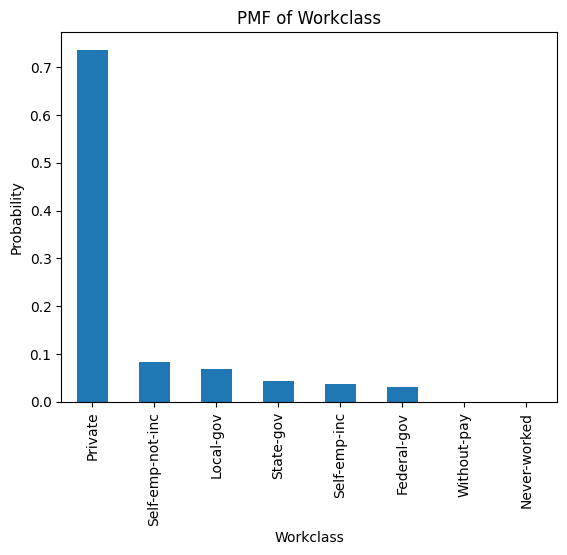

In [5]:
print('\n PMF of workclass')
workclass_dist=df['workclass'].value_counts(normalize=True)
print(workclass_dist)

plt.figure()
workclass_dist.plot(kind='bar')
plt.title('PMF of Workclass')
plt.xlabel('Workclass')
plt.ylabel('Probability')
plt.xticks(rotation=90)
plt.show()

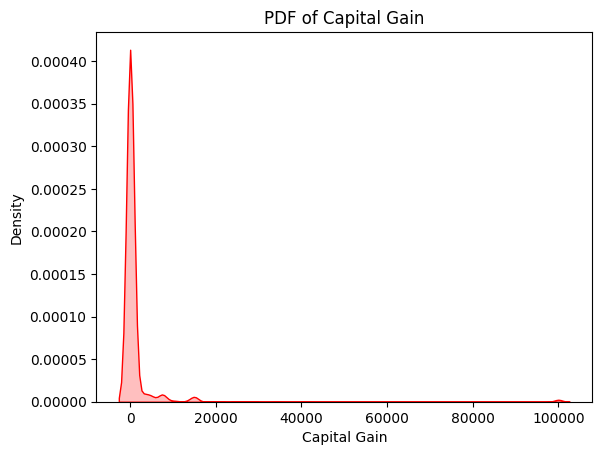

In [8]:
sns.kdeplot(df["capital-gain"], color='red', fill=True)
plt.title('PDF of Capital Gain')
plt.xlabel('Capital Gain')
plt.ylabel('Density')
plt.show()


In [9]:
joint_prob=pd.crosstab(df["occupation"],df['income'],normalize='all')

print('\n결합확률표 p(occupation, income)')
print(joint_prob)

print('\n결합확률표의 전체 합:',joint_prob.to_numpy().sum())


결합확률표 p(occupation, income)
income                <=50K      >50K
occupation                           
Adm-clerical       0.105207  0.016684
Armed-Forces       0.000217  0.000109
Craft-repair       0.102731  0.030044
Exec-managerial    0.069037  0.063172
Farming-fishing    0.028610  0.003758
Handlers-cleaners  0.042013  0.002998
Machine-op-inspct  0.057567  0.008081
Other-service      0.102513  0.004432
Priv-house-serv    0.005192  0.000065
Prof-specialty     0.073599  0.060478
Protective-serv    0.014663  0.006691
Sales              0.087524  0.032042
Tech-support       0.022288  0.009124
Transport-moving   0.040710  0.010449

결합확률표의 전체 합: 1.0


In [11]:
numeric_df=df[['age','hours-per-week']]

cov_matrix=numeric_df.cov()
corr_matrix=numeric_df.corr()

print('\n공분산 행렬')
print(cov_matrix)

print('\n상관계수 행렬')
print(corr_matrix)



공분산 행렬
                       age  hours-per-week
age             174.352685       16.206246
hours-per-week   16.206246      144.265782

상관계수 행렬
                     age  hours-per-week
age             1.000000        0.102185
hours-per-week  0.102185        1.000000
